In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Find project root even if notebook is opened from notebooks/
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS_SYN = ROOT / "results_n2000"
RESULTS_NAT = ROOT / "natural_abstraction" / "results_natural"

print("Project root:", ROOT)
print("Synthetic results dir exists:", RESULTS_SYN.exists(), RESULTS_SYN)
print("Natural results dir exists:", RESULTS_NAT.exists(), RESULTS_NAT)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

Project root: c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project
Synthetic results dir exists: True c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project\results_n2000
Natural results dir exists: True c:\Users\Melvi\Downloads\research_seminar\vision_abstraction_project\natural_abstraction\results_natural


In [2]:
# Synthetic summary CSVs
sum_app_clip = pd.read_csv(RESULTS_SYN / "summary_corruptions_appearance_openclip.csv")
sum_geo_clip = pd.read_csv(RESULTS_SYN / "summary_corruptions_geometry_openclip.csv")
sum_app_eff = pd.read_csv(RESULTS_SYN / "summary_corruptions_appearance_efficientnet.csv")
sum_geo_eff = pd.read_csv(RESULTS_SYN / "summary_corruptions_geometry_efficientnet.csv")

fail_app_clip = pd.read_csv(RESULTS_SYN / "failure_corruptions_appearance_openclip.csv")
fail_geo_clip = pd.read_csv(RESULTS_SYN / "failure_corruptions_geometry_openclip.csv")
fail_app_eff = pd.read_csv(RESULTS_SYN / "failure_corruptions_appearance_efficientnet.csv")
fail_geo_eff = pd.read_csv(RESULTS_SYN / "failure_corruptions_geometry_efficientnet.csv")

drift_clip_app = pd.read_csv(RESULTS_SYN / "embedding_drift_openclip_appearance.csv")
drift_clip_geo = pd.read_csv(RESULTS_SYN / "embedding_drift_openclip_geometry.csv")
drift_eff_app = pd.read_csv(RESULTS_SYN / "embedding_drift_efficientnet_appearance.csv")
drift_eff_geo = pd.read_csv(RESULTS_SYN / "embedding_drift_efficientnet_geometry.csv")
drift_dino_app = pd.read_csv(RESULTS_SYN / "embedding_drift_dino_appearance.csv")
drift_dino_geo = pd.read_csv(RESULTS_SYN / "embedding_drift_dino_geometry.csv")

# Natural baseline CSVs
nat_clip_class = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_openclip_by_class.csv")
nat_clip_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_openclip_by_subtype.csv")
nat_clip_class_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_openclip_by_class_subtype.csv")

nat_eff_class = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_efficientnet_by_class.csv")
nat_eff_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_efficientnet_by_subtype.csv")
nat_eff_class_subtype = pd.read_csv(RESULTS_NAT / "summary_baseline_natural_efficientnet_by_class_subtype.csv")

nat_conf_overall = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_overall.csv")

nat_drift_class = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_class.csv")
nat_drift_subtype = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_subtype.csv")
nat_drift_class_subtype = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_class_subtype.csv")

print("Loaded all main CSVs.")

Loaded all main CSVs.


In [3]:
def plot_openclip_synthetic(df, title):
    plt.figure(figsize=(7,4))
    for t in sorted(df["transform"].unique()):
        sub = df[df["transform"] == t]
        plt.plot(sub["level"], sub["accuracy"], marker="o", label=t)
    plt.xlabel("Severity Level")
    plt.ylabel("Accuracy (OpenCLIP)")
    plt.title(title)
    plt.legend()
    plt.show()


def plot_effnet_synthetic(df, title):
    plt.figure(figsize=(7,4))
    for t in sorted(df["transform"].unique()):
        sub = df[df["transform"] == t]
        plt.plot(sub["level"], sub["mean_confidence"], marker="o", label=t)
    plt.xlabel("Severity Level")
    plt.ylabel("Mean Confidence (EfficientNet)")
    plt.title(title)
    plt.legend()
    plt.show()


def plot_drift(df, title, ycol="mean_drift"):
    plt.figure(figsize=(7,4))
    for t in sorted(df["transform"].unique()):
        sub = df[df["transform"] == t]
        plt.plot(sub["level"], sub[ycol], marker="o", label=t)
    plt.xlabel("Severity Level")
    plt.ylabel(ycol.replace("_", " ").title())
    plt.title(title)
    plt.legend()
    plt.show()

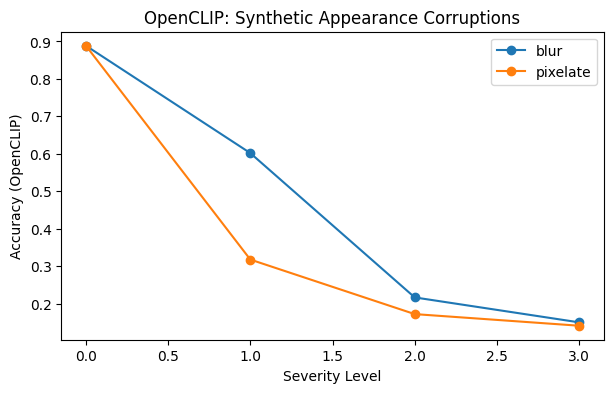

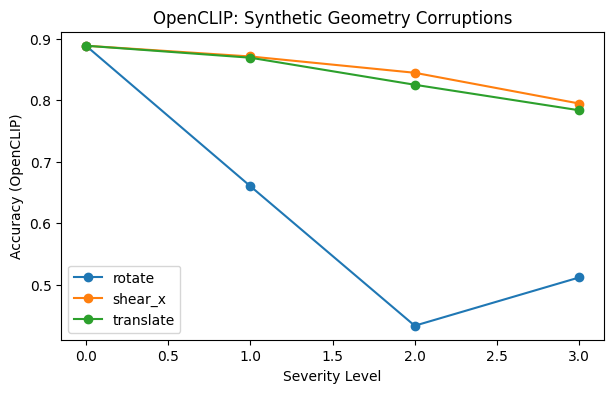

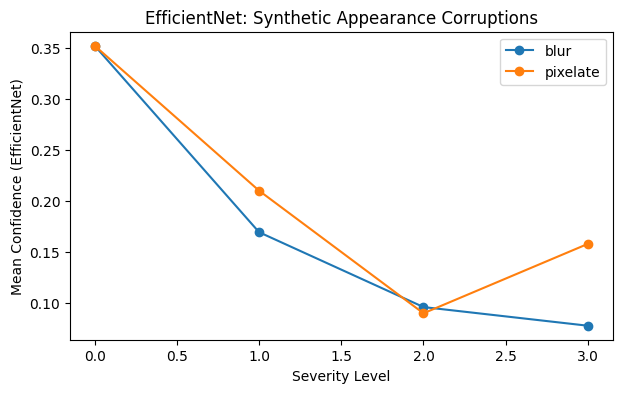

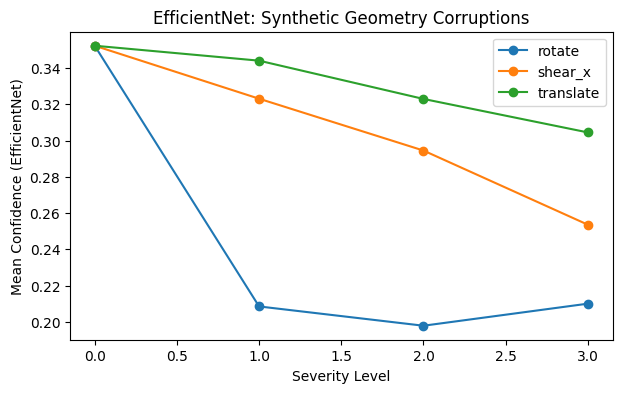

In [ ]:
plot_openclip_synthetic(sum_app_clip, "OpenCLIP: Synthetic Appearance Corruptions")
plot_openclip_synthetic(sum_geo_clip, "OpenCLIP: Synthetic Geometry Corruptions")

plot_effnet_synthetic(sum_app_eff, "EfficientNet: Synthetic Appearance Corruptions")
plot_effnet_synthetic(sum_geo_eff, "EfficientNet: Synthetic Geometry Corruptions")-

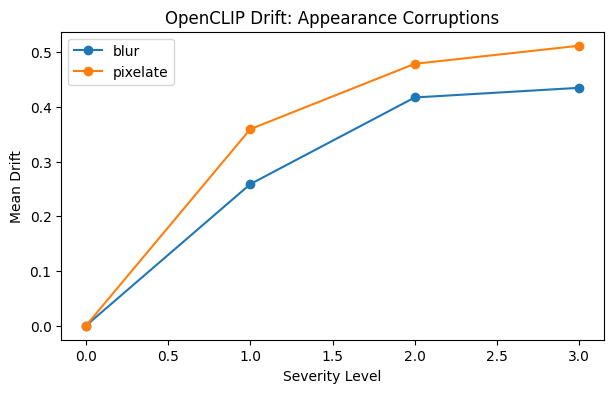

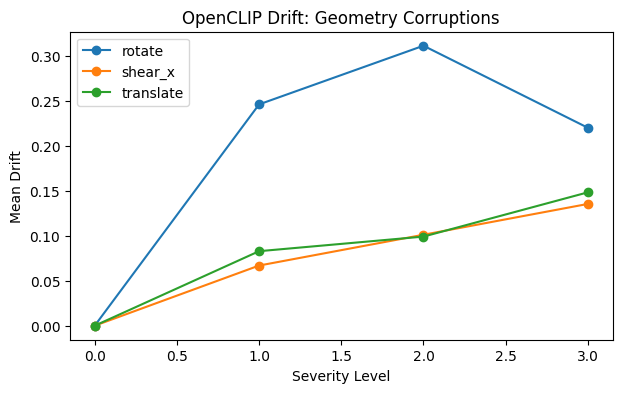

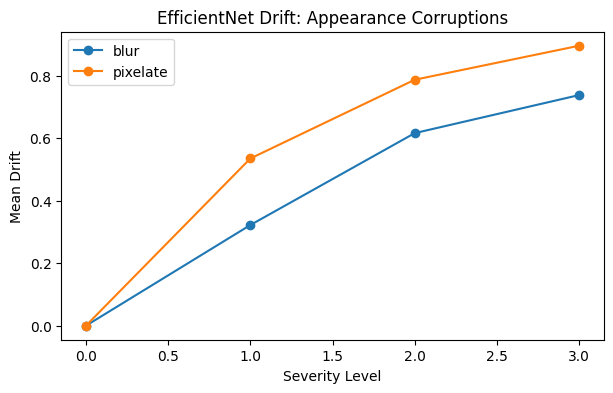

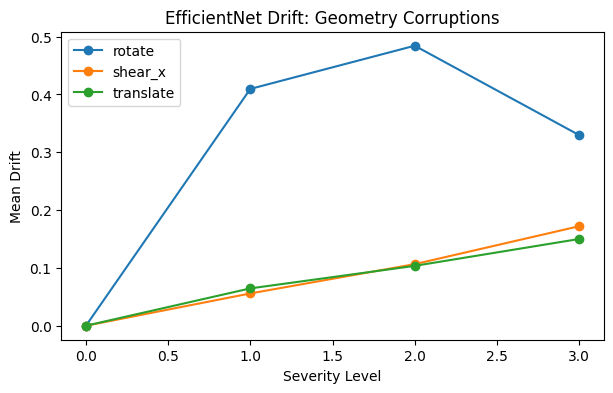

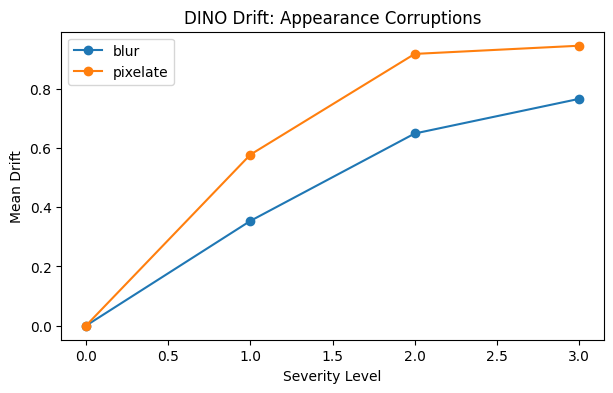

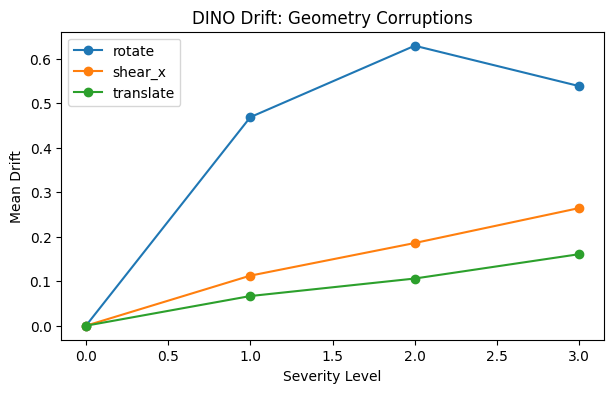

In [5]:
plot_drift(drift_clip_app, "OpenCLIP Drift: Appearance Corruptions")
plot_drift(drift_clip_geo, "OpenCLIP Drift: Geometry Corruptions")

plot_drift(drift_eff_app, "EfficientNet Drift: Appearance Corruptions")
plot_drift(drift_eff_geo, "EfficientNet Drift: Geometry Corruptions")

plot_drift(drift_dino_app, "DINO Drift: Appearance Corruptions")
plot_drift(drift_dino_geo, "DINO Drift: Geometry Corruptions")

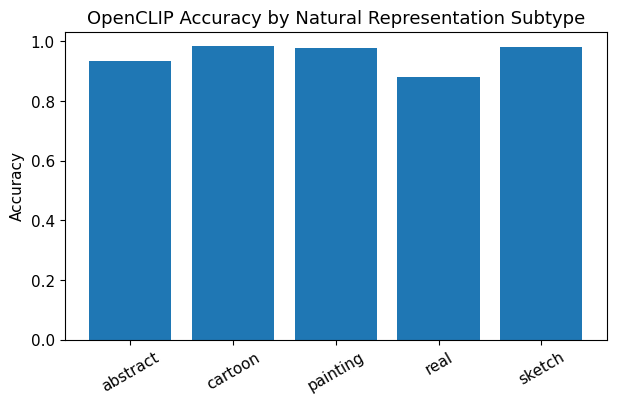

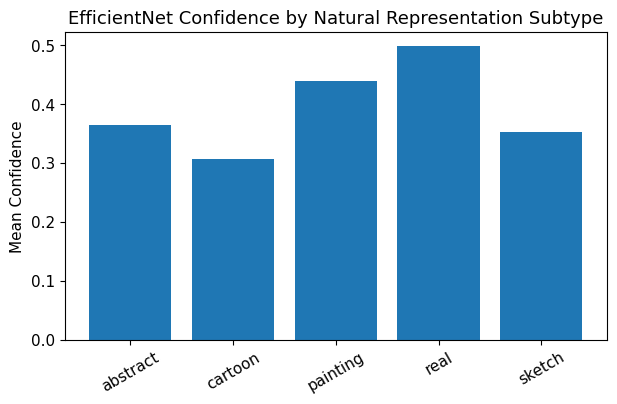

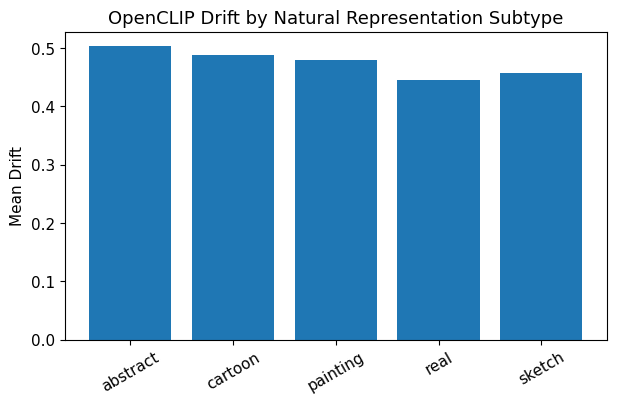

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7,4))
plt.bar(nat_clip_subtype["subtype"], nat_clip_subtype["accuracy"])
plt.title("OpenCLIP Accuracy by Natural Representation Subtype")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(7,4))
plt.bar(nat_eff_subtype["subtype"], nat_eff_subtype["mean_confidence"])
plt.title("EfficientNet Confidence by Natural Representation Subtype")
plt.ylabel("Mean Confidence")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(7,4))
plt.bar(nat_drift_subtype["subtype"], nat_drift_subtype["mean_drift"])
plt.title("OpenCLIP Drift by Natural Representation Subtype")
plt.ylabel("Mean Drift")
plt.xticks(rotation=30)
plt.show()

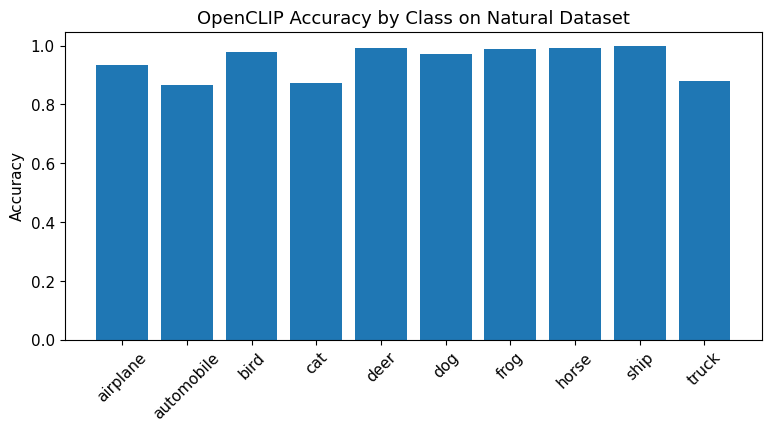

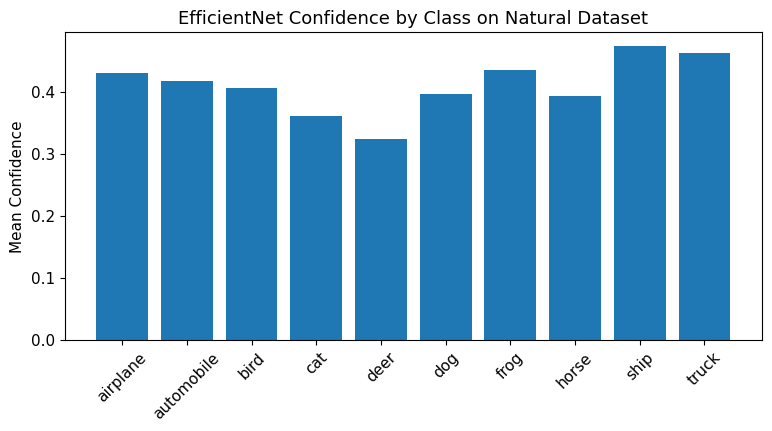

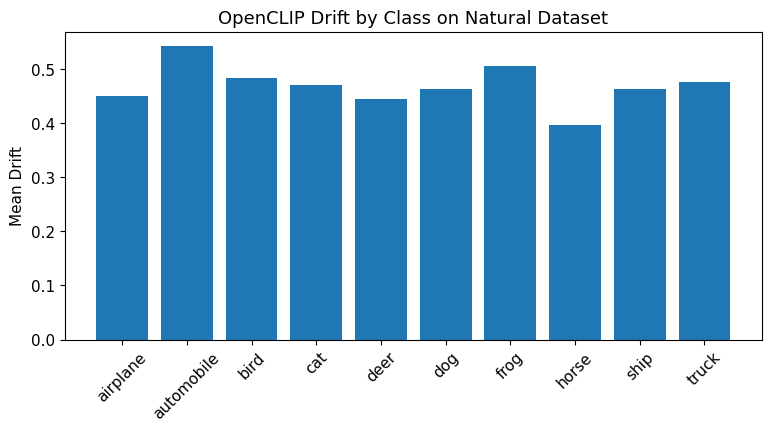

In [15]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7,4),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "grid.alpha": 0.3
})

plt.figure(figsize=(9,4))
plt.bar(nat_clip_class["true_label_name"], nat_clip_class["accuracy"])
plt.title("OpenCLIP Accuracy by Class on Natural Dataset")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(9,4))
plt.bar(nat_eff_class["true_label_name"], nat_eff_class["mean_confidence"])
plt.title("EfficientNet Confidence by Class on Natural Dataset")
plt.ylabel("Mean Confidence")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(9,4))
plt.bar(nat_drift_class["true_label_name"], nat_drift_class["mean_drift"])
plt.title("OpenCLIP Drift by Class on Natural Dataset")
plt.ylabel("Mean Drift")
plt.xticks(rotation=45)
plt.show()

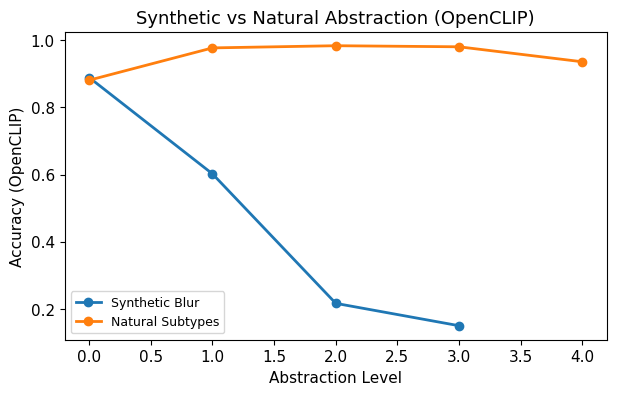

In [22]:

import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7,4),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "grid.alpha": 0.3
})

mapping = {
    "real": 0,
    "painting": 1,
    "cartoon": 2,
    "sketch": 3,
    "abstract": 4,
}

nat_cross = nat_clip_subtype.copy()
nat_cross["level"] = nat_cross["subtype"].map(mapping)
nat_cross = nat_cross.sort_values("level")

# example synthetic comparison with appearance/blur
syn_blur = sum_app_clip[sum_app_clip["transform"] == "blur"].copy()

plt.figure(figsize=(7,4))
plt.plot(syn_blur["level"], syn_blur["accuracy"], marker="o", label="Synthetic Blur")
plt.plot(nat_cross["level"], nat_cross["accuracy"], marker="o", label="Natural Subtypes")
plt.xlabel("Abstraction Level")
plt.ylabel("Accuracy (OpenCLIP)")
plt.title("Synthetic vs Natural Abstraction (OpenCLIP)")
plt.legend()
plt.show()

In [10]:
nat_clip_class_subtype.sort_values(["true_label_name", "subtype"]).head(50)
nat_drift_class_subtype.sort_values(["true_label_name", "subtype"]).head(50)

,true_label_name,subtype,mean_cosine_similarity,mean_drift,n
0,airplane,abstract,0.510265,0.489735,124
1,airplane,cartoon,0.546480,0.453520,113
2,airplane,painting,0.544440,0.455560,120
3,airplane,real,0.559512,0.440488,312
4,airplane,sketch,0.584001,0.415999,98
5,automobile,abstract,0.474902,0.525098,105
6,automobile,cartoon,0.517896,0.482104,108
7,automobile,painting,0.469032,0.530968,94
8,automobile,real,0.415337,0.584663,351
9,automobile,sketch,0.516510,0.483490,97


In [11]:
conf_abstract = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_abstract.csv", index_col=0)
conf_cartoon = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_cartoon.csv", index_col=0)
conf_painting = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_painting.csv", index_col=0)
conf_real = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_real.csv", index_col=0)
conf_sketch = pd.read_csv(RESULTS_NAT / "confusion_baseline_natural_openclip_sketch.csv", index_col=0)

conf_real

,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
true,,,,,,,,,,
airplane,291,4,0,0,0,0,0,0,14,3
automobile,4,257,2,0,2,0,0,8,32,46
bird,0,0,255,0,9,0,4,1,0,0
cat,1,2,6,162,60,9,9,0,0,4
deer,0,0,1,0,129,0,1,0,0,0
dog,0,0,0,0,0,104,0,0,0,0
frog,0,0,0,0,0,0,122,0,0,0
horse,0,0,0,0,0,0,0,102,0,0
ship,0,0,0,0,0,0,0,0,109,0


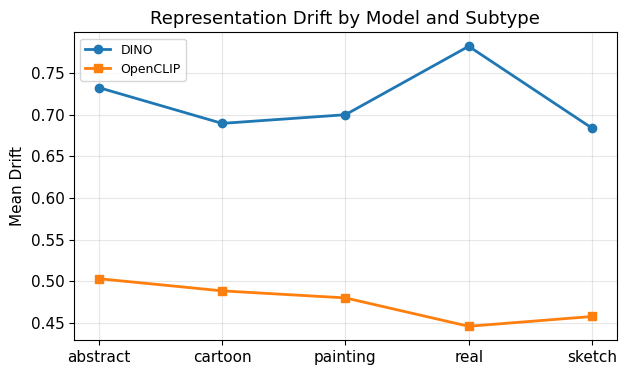

In [18]:
dino = pd.read_csv(RESULTS_NAT / "dino_natural_drift_by_subtype.csv")
clip = pd.read_csv(RESULTS_NAT / "openclip_natural_drift_by_subtype.csv")
plt.figure()

plt.plot(dino["subtype"], dino["mean_drift"], marker="o", label="DINO")
plt.plot(clip["subtype"], clip["mean_drift"], marker="s", label="OpenCLIP")

plt.ylabel("Mean Drift")
plt.title("Representation Drift by Model and Subtype")
plt.legend()
plt.grid(True)
plt.show()

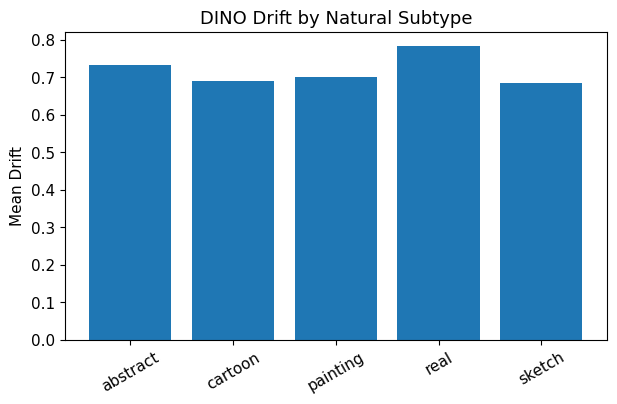

In [20]:
plt.figure(figsize=(7,4))
plt.bar(dino["subtype"], dino["mean_drift"])
plt.title("DINO Drift by Natural Subtype")
plt.ylabel("Mean Drift")
plt.xticks(rotation=30)
plt.show()

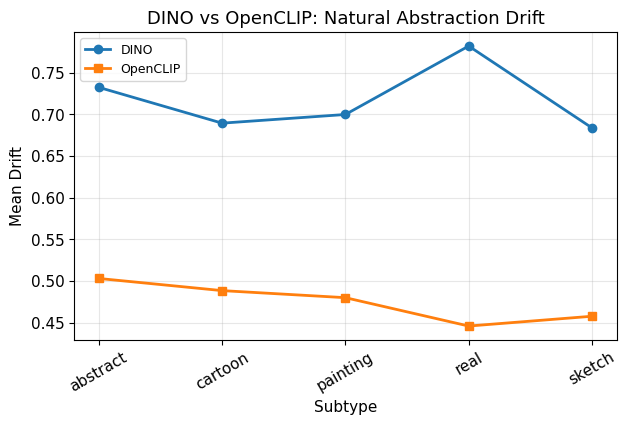

In [21]:
plt.figure(figsize=(7,4))

plt.plot(dino["subtype"], dino["mean_drift"], marker="o", label="DINO")
plt.plot(clip["subtype"], clip["mean_drift"], marker="s", label="OpenCLIP")

plt.title("DINO vs OpenCLIP: Natural Abstraction Drift")
plt.ylabel("Mean Drift")
plt.xlabel("Subtype")
plt.legend()
plt.grid(True)
plt.xticks(rotation=30)

plt.show()

In [23]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RESULTS_NAT = ROOT / "natural_abstraction" / "results_natural"

nat_meta = pd.read_csv(RESULTS_NAT / "natural_dino_metadata.csv")
cifar_meta = pd.read_csv(RESULTS_NAT / "cifar_baseline_dino_metadata.csv")

print("Natural DINO columns:", list(nat_meta.columns))
print("CIFAR DINO columns:", list(cifar_meta.columns))

display(nat_meta.head())
display(cifar_meta.head())

Natural DINO columns: ['image_id', 'image_path', 'true_label', 'true_label_name', 'subtype']
CIFAR DINO columns: ['image_id', 'image_path', 'true_label', 'true_label_name']


,image_id,image_path,true_label,true_label_name,subtype
0,0,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane,abstract
1,1,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane,abstract
2,2,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane,abstract
3,3,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane,abstract
4,4,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane,abstract


,image_id,image_path,true_label,true_label_name
0,0,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane
1,1,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane
2,2,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane
3,3,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane
4,4,C:\Users\Melvi\Downloads\research_seminar\visi...,0,airplane
